In [1]:
from model.model import PoseModel
import torch
from data.dataset import LinemodDataset

import cv2
import numpy as np

from utils.predictions import estimate_pose
from utils.visualization import show_all

from tqdm import tqdm

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


# Loading the model

In [2]:
checkpoint_path="checkpoints/best.pth"

In [3]:
model = PoseModel(num_objects=15).to("cuda")

    # Carica checkpoint
checkpoint = torch.load(checkpoint_path, map_location="cuda")

    # Carica pesi
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

/home/raciard/.conda/envs/tp3d/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/raciard/.conda/envs/tp3d/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


PoseModel(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_

# Loading the dataset

In [4]:
dataset_root = "datasets/Linemod_preprocessed/"

val_dataset = LinemodDataset(dataset_root, split='test')



# Making a prediction and visualizing the corresponding 3d bb

sample number 1416, 
tensor(14)


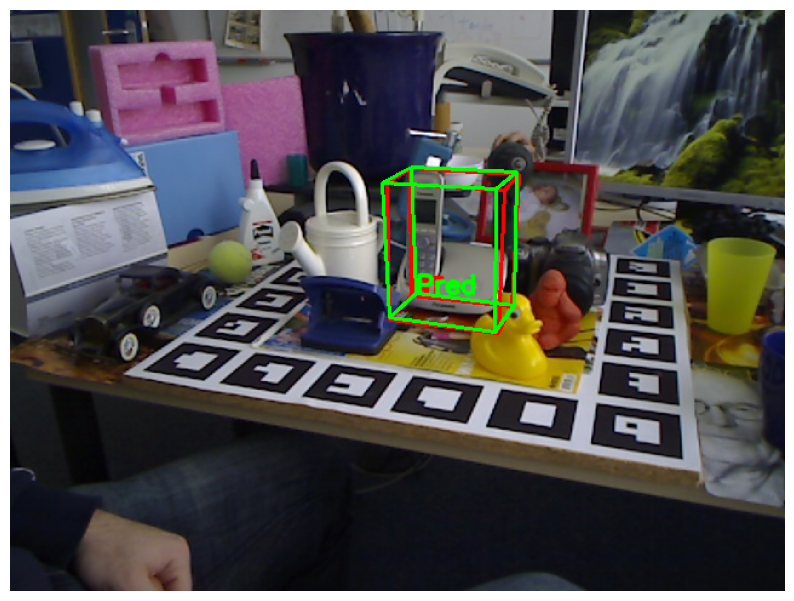

In [5]:
import random
random.seed()
sample_id =random.randint(0,len(val_dataset))
print(f"sample number {sample_id}, ")

pred_r, pred_t, _ = estimate_pose(model, val_dataset, sample_id)





print(val_dataset[sample_id]['obj_id'])

show_all(val_dataset[sample_id], pred_r, pred_t)

In [6]:
import os

In [7]:
def get_3d_model_path(dataset_root, obj_id):
    print(obj_id)
    return os.path.join(dataset_root, 'models', f"obj_{obj_id+1:02d}.ply")

In [8]:
from metrics.add import compute_add, compute_add_percent, compute_adds, compute_adds_percent

In [9]:
sample = val_dataset[sample_id]

In [10]:
model_path = get_3d_model_path(dataset_root,sample['obj_id'])

tensor(14)


In [11]:
compute_add(model_path, sample['rotation'], sample['translation'], pred_r, pred_t)

np.float64(5.893914659776833)

In [12]:
compute_add_percent(model_path, sample['rotation'], sample['translation'], pred_r,pred_t)

(np.float64(5.893914659776833),
 np.float64(97.68266281294679),
 np.float64(254.33996799023015))

In [13]:
compute_adds_percent(model_path, sample['rotation'], sample['translation'], pred_r,pred_t)

(np.float64(3.2270906529247183),
 np.float64(98.7311901159598),
 np.float64(254.33996799023015))

In [14]:
from utils.refine_pose import refine_pose
import refiner.refiner
import utils.refine_pose
import importlib
importlib.reload(utils.refine_pose)
importlib.reload(refiner.refiner)

<module 'refiner.refiner' from '/home/raciard/mldl/mldl_project/refiner/refiner.py'>

In [15]:
refined_r, refined_t, losses = refine_pose(model_path, sample, pred_r, pred_t, num_iters=200,verbose=True, lr=5e-3)

[0/200] Loss: 0.000244
[1/200] Loss: 0.000620
[2/200] Loss: 0.001710
[3/200] Loss: 0.003846
[4/200] Loss: 0.003842
[5/200] Loss: 0.003763
[6/200] Loss: 0.003480
[7/200] Loss: 0.003604
[8/200] Loss: 0.003755
[9/200] Loss: 0.003974
[10/200] Loss: 0.004413
[11/200] Loss: 0.004881
[12/200] Loss: 0.005150
[13/200] Loss: 0.005345
[14/200] Loss: 0.005485
[15/200] Loss: 0.005741
[16/200] Loss: 0.006010
[17/200] Loss: 0.006889
[18/200] Loss: 0.008084
[19/200] Loss: 0.009460
[20/200] Loss: 0.011427
[21/200] Loss: 0.012305
[22/200] Loss: 0.012325
[23/200] Loss: 0.012374
[24/200] Loss: 0.011971
[25/200] Loss: 0.011617
[26/200] Loss: 0.011415
[27/200] Loss: 0.011175
[28/200] Loss: 0.010527
[29/200] Loss: 0.009861
[30/200] Loss: 0.008842
Early stopping at iteration 30, best loss: 0.000244


In [16]:
compute_add_percent(model_path, sample['rotation'], sample['translation'], pred_r, pred_t)

(np.float64(5.893914659776833),
 np.float64(97.68266281294679),
 np.float64(254.33996799023015))

In [17]:
compute_add_percent(model_path, sample['rotation'], sample['translation'], refined_r, refined_t)

(np.float64(7.224208409056339),
 np.float64(97.15962517958097),
 np.float64(254.33996799023015))

In [20]:
r_ref = refined_r
t_ref = refined_t

In [21]:
losses

[0.0008609461365267634,
 0.0008591628284193575,
 0.0008841985836625099,
 0.0009364623110741377,
 0.0009828605689108372,
 0.0011127513134852052,
 0.0011952463537454605,
 0.0012741261161863804,
 0.0010093176970258355,
 0.000709253188688308,
 0.0005854343180544674,
 0.0005422997637651861,
 0.0006250310689210892,
 0.0006991748814471066,
 0.000841320026665926,
 0.0008509077015332878,
 0.0007833888521417975,
 0.0005803313688375056,
 0.000506900716573,
 0.0005427134456112981,
 0.0006401342106983066,
 0.0007730238139629364,
 0.0008036081562750041,
 0.0008200625889003277,
 0.000827485928311944,
 0.000710311986040324,
 0.0006601610803045332,
 0.0005635646521113813,
 0.0005607852945104241,
 0.0006308953161351383,
 0.0008085100562311709,
 0.0007401774055324495,
 0.0007260547135956585,
 0.0007229996263049543,
 0.0006424972089007497,
 0.0006431053043343127,
 0.0007226566085591912,
 0.0006880725850351155,
 0.000718250754289329,
 0.0007471420685760677,
 0.000663330196402967,
 0.0006633226294070482,
 0

In [ ]:
add_perc_cum = 0
n_ok = 0
n_ok_per_obj = {}
n_tot_per_obj = dict()
symmetrical = {9,10}
for sample_id in tqdm(range(len(val_dataset))):
    try:
        sample = val_dataset[sample_id]
        obj_id = int(sample['obj_id'])
        pred_r, pred_t, _ = estimate_pose(model, val_dataset, sample_id)
        model_path = get_3d_model_path(dataset_root, obj_id)
        refined_r, refined_t, losses = refine_pose(model_path, sample, pred_r, pred_t, num_iters=50, lr=2e-3)
        r_ref = refined_r.cpu().detach().squeeze().numpy()
        t_ref = refined_t.cpu().detach().numpy() * 1000
        if obj_id not in symmetrical:
            add_abs, add_perc, _ = compute_add_percent(model_path, sample['rotation'], sample['translation'], r_ref, t_ref)
        else:
            add_abs, add_perc, _ = compute_adds_percent(model_path, sample['rotation'], sample['translation'], r_ref, t_ref)
    
        add_perc_cum = add_perc_cum + add_perc
        if obj_id not in n_tot_per_obj:
            n_tot_per_obj[obj_id] = 0
            n_ok_per_obj[obj_id] = 0
    
        if add_perc > 90:
            n_ok+=1
            n_ok_per_obj[obj_id] += 1
        n_tot_per_obj[obj_id] +=1
        curr_perc = add_perc_cum / (sample_id + 1)
        curr_ok_perc = n_ok / (sample_id + 1) * 100
        curr_ok_perc_obj = (n_ok_per_obj[obj_id] if obj_id in n_ok_per_obj else 0) / n_tot_per_obj[obj_id] * 100
    
        print(f"Current add: {curr_perc}%")
        print(f"Current ok perc: {curr_ok_perc}")
        print(f"Current ok perc per obj {obj_id}: {curr_ok_perc_obj}")
    except Exception as e:
        continue

    

In [ ]:
val_dataset[4]

In [ ]:
n_ok_per_obj

In [ ]:
n_tot_per_obj

In [ ]:
curr_ok_perc_obj

In [ ]:
n_ok_per_o

In [ ]:
from joblib import Parallel, delayed
from tqdm import tqdm
from collections import defaultdict

add_perc_cum = 0
n_ok = 0
n_ok_per_obj = defaultdict(int)
n_tot_per_obj = defaultdict(int)
symmetrical = {9, 10}

def process_sample(sample_id):
    try:
        sample = val_dataset[sample_id]
        obj_id = int(sample['obj_id'])
        pred_r, pred_t, _ = estimate_pose(model, val_dataset, sample_id)
        model_path = get_3d_model_path(dataset_root, obj_id)
        refined_r, refined_t, losses = refine_pose(model_path, sample, pred_r, pred_t, num_iters=50, lr=2e-3)
        r_ref = refined_r.cpu().detach().squeeze().numpy()
        t_ref = refined_t.cpu().detach().numpy() * 1000
        
        if obj_id not in symmetrical:
            add_abs, add_perc, _ = compute_add_percent(model_path, sample['rotation'], sample['translation'], r_ref, t_ref)
        else:
            add_abs, add_perc, _ = compute_adds_percent(model_path, sample['rotation'], sample['translation'], r_ref, t_ref)
        
        is_ok = add_perc > 90
        return sample_id, obj_id, add_perc, is_ok
    except Exception as e:
        return None

results = Parallel(n_jobs=8)(delayed(process_sample)(i) for i in tqdm(range(len(val_dataset))))

# Post-processing aggregato
for res in results:
    if res is None:
        continue
    sample_id, obj_id, add_perc, is_ok = res
    add_perc_cum += add_perc
    n_tot_per_obj[obj_id] += 1
    if is_ok:
        n_ok += 1
        n_ok_per_obj[obj_id] += 1

    curr_perc = add_perc_cum / (sample_id + 1)
    curr_ok_perc = n_ok / (sample_id + 1) * 100
    curr_ok_perc_obj = n_ok_per_obj[obj_id] / n_tot_per_obj[obj_id] * 100

    print(f"Current add: {curr_perc:.2f}%")
    print(f"Current ok perc: {curr_ok_perc:.2f}")
    print(f"Current ok perc per obj {obj_id}: {curr_ok_perc_obj:.2f}")


In [20]:
n_ok_per_obj

defaultdict(int,
            {4: 239,
             0: 236,
             12: 223,
             1: 222,
             13: 237,
             14: 215,
             7: 230,
             8: 246,
             3: 225,
             9: 259,
             10: 241,
             11: 225,
             5: 235})

In [21]:
n_tot_per_obj

defaultdict(int,
            {4: 253,
             0: 246,
             12: 234,
             1: 223,
             13: 240,
             14: 226,
             7: 234,
             8: 270,
             3: 239,
             9: 259,
             10: 249,
             11: 239,
             5: 242})

In [25]:
perc_per_obj = {i: n_ok_per_obj[i]/n_tot_per_obj[i] * 100 for i in n_tot_per_obj.keys()}

In [26]:
perc_per_obj

{4: 94.46640316205533,
 0: 95.9349593495935,
 12: 95.2991452991453,
 1: 99.55156950672645,
 13: 98.75,
 14: 95.13274336283186,
 7: 98.29059829059828,
 8: 91.11111111111111,
 3: 94.14225941422593,
 9: 100.0,
 10: 96.78714859437751,
 11: 94.14225941422593,
 5: 97.10743801652893}

13
3
10
13
12
7
14
0
13
0
14
3
7
3
12
0
4
11
10
5
4
9
12
8
8
1
11
12
9
11
8
12
0
1
12
8
10
7
4
12
11
4
7
12
9
4
10
8
8
8
4
10
10
14
5
7
13
4
14
3
1
12
8
11
3
14
3
13
11
9
3
5
5
12
11
9
3
14
10
11
7
4
11
14
8
4
14
11
8
11
8
0
14
13
10
3
12
0
8
5
12
0
8
5
8
10
3
8
13
9
4
11
1
4
10
10
14
8
10
12
8
1
7
11
3
8
10
10
8
13
3
3
9
8
5
13
5
10
14
3
11
11
1
3
4
4
14
3
1
11
11
14
3
9
5
10
1
7
10
7
0
1
11
13
1
12
1
4
5
12
7
11
4
7
10
10
12
3
11
8
4
12
5
7
4
1
0
13
7
12
3
8
8
9
4
4
12
3
1
0
0
4
3
9
1
12
7
4
9
13
5
13
10
10
11
9
8
13
9
12
10
13
4
4
13
3
1
9
11
14
0
13
3
10
5
14
14
12
1
10
9
1
8
5
1
0
1
3
1
5
8
3
3
9
11
4
3
1
9
9
11
14
3
10
10
4
1
8
9
11
7
10
0
4
5
8
10
8
7
5
1
5
10
4
9
3
8
3
9
9
10
13
5
3
11
10
11
11
13
9
0
4
1
7
4
13
8
5
8
0
8
7
1
5
10
9
12
3
12
10
3
11
8
7
3
0
5
3
9
13
8
11
13
7
13
1
4
13
3
0
1
8
4
11
14
13
1
4
10
14
13
5
4
5
12
5
13
3
14
4
10
9
7
14
0
12
13
8
14
14
3
4
7
10
9
13
3
4
3
0
10
14
1
12
8
12
1
7
14
8
12
13
11
5
11
10
11
9
10
12
10
10
14
11
11
10
1
5
8
1
8
14
9
5
11
8
11

In [19]:
from joblib import Parallel, delayed
from tqdm import tqdm
from collections import defaultdict

add_perc_cum = 0
n_ok = 0
n_ok_per_obj = defaultdict(int)
n_tot_per_obj = defaultdict(int)
symmetrical = {9, 10}

def process_sample(sample_id):
    try:
        sample = val_dataset[sample_id]
        obj_id = int(sample['obj_id'])
        pred_r, pred_t, _ = estimate_pose(model, val_dataset, sample_id)
        model_path = get_3d_model_path(dataset_root, obj_id)

        # Usa direttamente la predizione senza refine
        r_pred = pred_r
        t_pred = pred_t

        if obj_id not in symmetrical:
            add_abs, add_perc, _ = compute_add_percent(model_path, sample['rotation'], sample['translation'], r_pred, t_pred)
        else:
            add_abs, add_perc, _ = compute_adds_percent(model_path, sample['rotation'], sample['translation'], r_pred, t_pred)

        is_ok = add_perc > 90
        return sample_id, obj_id, add_perc, is_ok
    except Exception as e:
        print(e)
        return None

results = Parallel(n_jobs=8)(delayed(process_sample)(i) for i in tqdm(range(len(val_dataset))))

# Post-processing aggregato
for res in results:
    if res is None:
        continue
    sample_id, obj_id, add_perc, is_ok = res
    add_perc_cum += add_perc
    n_tot_per_obj[obj_id] += 1
    if is_ok:
        n_ok += 1
        n_ok_per_obj[obj_id] += 1

    curr_perc = add_perc_cum / (sample_id + 1)
    curr_ok_perc = n_ok / (sample_id + 1) * 100
    curr_ok_perc_obj = n_ok_per_obj[obj_id] / n_tot_per_obj[obj_id] * 100

    print(f"Current add: {curr_perc:.2f}%")
    print(f"Current ok perc: {curr_ok_perc:.2f}")
    print(f"Current ok perc per obj {obj_id}: {curr_ok_perc_obj:.2f}")



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3160/3160 [06:10<00:00,  8.54it/s]


Current add: 83.72%
Current ok perc: 0.00
Current ok perc per obj 4: 0.00
Current add: 86.34%
Current ok perc: 0.00
Current ok perc per obj 0: 0.00
Current add: 89.62%
Current ok perc: 33.33
Current ok perc per obj 4: 50.00
Current add: 88.92%
Current ok perc: 25.00
Current ok perc per obj 12: 0.00
Current add: 88.26%
Current ok perc: 20.00
Current ok perc per obj 1: 0.00
Current add: 89.77%
Current ok perc: 33.33
Current ok perc per obj 1: 50.00
Current add: 90.54%
Current ok perc: 42.86
Current ok perc per obj 13: 100.00
Current add: 90.93%
Current ok perc: 50.00
Current ok perc per obj 13: 100.00
Current add: 90.18%
Current ok perc: 44.44
Current ok perc per obj 12: 0.00
Current add: 90.80%
Current ok perc: 50.00
Current ok perc per obj 14: 100.00
Current add: 91.12%
Current ok perc: 54.55
Current ok perc per obj 7: 100.00
Current add: 91.25%
Current ok perc: 58.33
Current ok perc per obj 13: 100.00
Current add: 91.45%
Current ok perc: 61.54
Current ok perc per obj 8: 100.00
Current

In [20]:
perc_per_obj = {i: n_ok_per_obj[i]/n_tot_per_obj[i] * 100 for i in n_tot_per_obj.keys()}

In [22]:
perc_per_obj

{4: 75.09881422924902,
 0: 43.90243902439025,
 12: 75.21367521367522,
 1: 89.68609865470853,
 13: 85.41666666666666,
 14: 65.48672566371681,
 7: 83.33333333333334,
 8: 48.148148148148145,
 3: 65.27196652719665,
 9: 94.98069498069498,
 10: 82.74509803921568,
 11: 52.719665271966534,
 5: 54.132231404958674}